# Chặng 3 — Vận hành: Giao hàng, Trả hàng & Stockout

**Câu hỏi cốt lõi:** Trải nghiệm vận hành có phải nguyên nhân mất khách không?

**Câu hỏi BA team cần trả lời:**
1. Delivery lead time trung bình bao lâu? Region nào tệ nhất?
2. Return rate theo delivery lead time — giao trễ có dẫn đến trả hàng nhiều hơn không?
3. Stockout rate đồng đều giữa 4 category không, dù sức bán khác nhau?
4. Correlation giữa stockout rate với bounce rate và conversion — stockout có làm mất KH không?
5. Size nào có return rate cao đột biến?

**File sử dụng:** `shipments` · `returns` · `inventory` · `orders` · `products` · `geography` · `web_traffic`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
from pathlib import Path
from scipy import stats

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.2f}'.format)

INPUT_DIR = Path('input')

C_REV   = '#1D9E75'
C_BAD   = '#E24B4A'
C_WARN  = '#EF9F27'
C_GOOD  = '#378ADD'
C_VOL   = '#888780'
C_CAT   = ['#7F77DD','#1D9E75','#EF9F27','#E24B4A']

print('✅ Setup OK')

✅ Setup OK


## 1. Load data

In [2]:
shipments   = pd.read_csv(INPUT_DIR / 'shipments.csv',  parse_dates=['ship_date','delivery_date'])
returns     = pd.read_csv(INPUT_DIR / 'returns.csv',    parse_dates=['return_date'])
inventory   = pd.read_csv(INPUT_DIR / 'inventory.csv',  parse_dates=['snapshot_date'])
orders      = pd.read_csv(INPUT_DIR / 'orders.csv',     parse_dates=['order_date'])
order_items = pd.read_csv(INPUT_DIR / 'order_items.csv')
products    = pd.read_csv(INPUT_DIR / 'products.csv')
geography   = pd.read_csv(INPUT_DIR / 'geography.csv')
web         = pd.read_csv(INPUT_DIR / 'web_traffic.csv', parse_dates=['date'])

# Master join cho phân tích giao hàng
ship = shipments.merge(
    orders[['order_id','order_date','order_status','zip']], on='order_id', how='left'
).merge(
    geography[['zip','city','region','district']], on='zip', how='left'
)
ship['lead_time_days'] = (ship['delivery_date'] - ship['ship_date']).dt.days
ship['Year']  = ship['delivery_date'].dt.year
ship['Month'] = ship['delivery_date'].dt.month
ship['YearMonth'] = ship['delivery_date'].dt.to_period('M')

# Master join cho phân tích trả hàng
ret = returns.merge(
    orders[['order_id','order_status','zip']], on='order_id', how='left'
).merge(
    order_items[['order_id','product_id','quantity','unit_price']]
        .drop_duplicates(['order_id','product_id']),
    on=['order_id','product_id'], how='left'
).merge(
    products[['product_id','category','segment','size','color']], on='product_id', how='left'
).merge(
    geography[['zip','region']], on='zip', how='left'
)
ret['Year']  = ret['return_date'].dt.year
ret['Month'] = ret['return_date'].dt.month
ret['YearMonth'] = ret['return_date'].dt.to_period('M')

# Delivered orders (để tính return rate chính xác)
delivered = orders[orders['order_status'] == 'delivered']

print(f'Shipments: {len(ship):,} | valid lead time: {ship["lead_time_days"].notna().sum():,}')
print(f'Returns  : {len(ret):,}')
print(f'Inventory snapshots: {len(inventory):,}')
print(f'\nLead time overview (ngày):')
print(ship['lead_time_days'].describe().round(1).to_string())

Shipments: 566,067 | valid lead time: 566,067
Returns  : 39,939
Inventory snapshots: 60,247

Lead time overview (ngày):
count   566,067.00
mean          4.50
std           1.70
min           2.00
25%           3.00
50%           4.00
75%           6.00
max           7.00


## 2. Delivery Lead Time — tổng quan và theo Region

**BA team hỏi:** Đơn hàng shipped bao lâu mới delivered? Region nào chậm nhất?

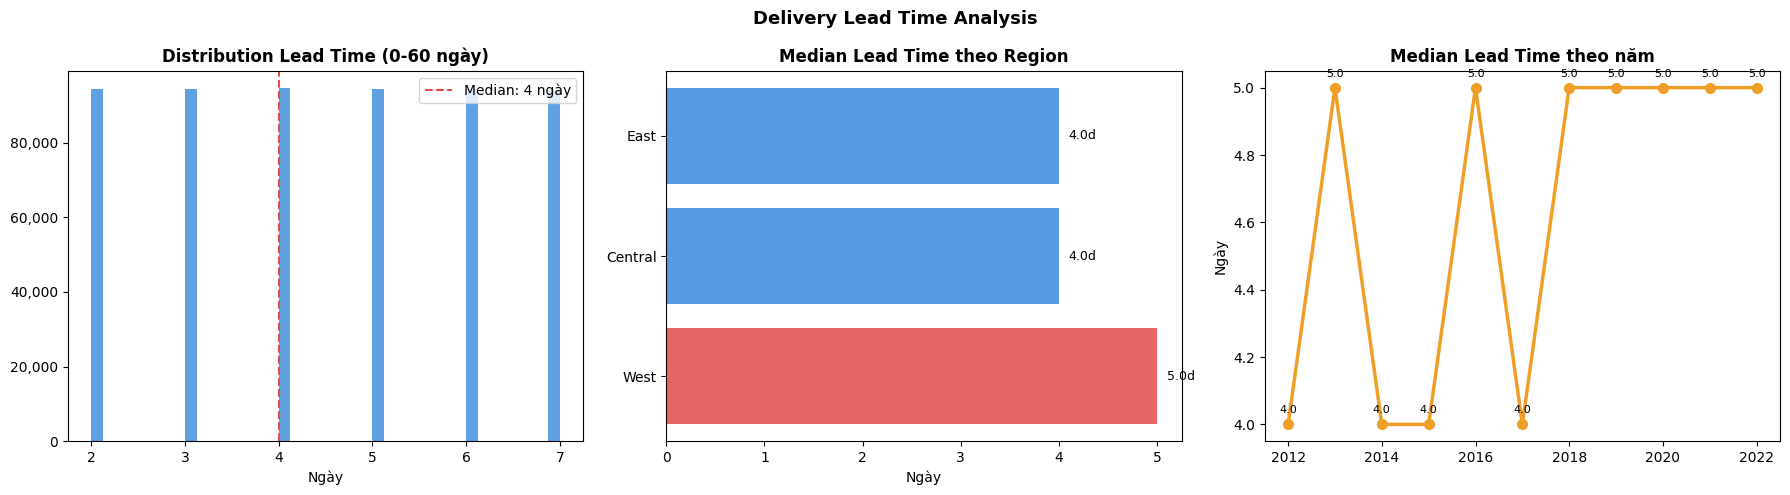

Lead Time theo Region:
 region  mean  median  count
   West  4.50    5.00 146923
Central  4.50    4.00 161388
   East  4.50    4.00 257756

% đơn giao trong 3 ngày : 33.3%
% đơn giao trong 7 ngày : 100.0%
% đơn giao >14 ngày     : 0.0%


In [3]:
ship_valid = ship[ship['lead_time_days'].between(0, 60)].copy()  # loại outlier

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Delivery Lead Time Analysis', fontsize=13, fontweight='bold')

# Distribution tổng thể
ax = axes[0]
ax.hist(ship_valid['lead_time_days'], bins=40, color=C_GOOD, alpha=0.8, edgecolor='none')
median_lt = ship_valid['lead_time_days'].median()
ax.axvline(median_lt, color=C_BAD, linestyle='--', linewidth=1.5,
           label=f'Median: {median_lt:.0f} ngày')
ax.set_title('Distribution Lead Time (0-60 ngày)', fontweight='bold')
ax.set_xlabel('Ngày')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

# Theo Region
lt_region = ship_valid.groupby('region')['lead_time_days'].agg(
    ['mean','median','count']
).round(1).reset_index().sort_values('median', ascending=False)

ax = axes[1]
bars = ax.barh(lt_region['region'], lt_region['median'],
               color=[C_BAD if v > median_lt else C_GOOD for v in lt_region['median']],
               alpha=0.85)
ax.set_title('Median Lead Time theo Region', fontweight='bold')
ax.set_xlabel('Ngày')
for bar, val in zip(bars, lt_region['median']):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}d', va='center', fontsize=9)

# Trend lead time theo năm
lt_year = ship_valid.groupby('Year')['lead_time_days'].median().reset_index()
ax = axes[2]
ax.plot(lt_year['Year'], lt_year['lead_time_days'],
        color=C_WARN, marker='o', linewidth=2.5, markersize=7)
ax.set_title('Median Lead Time theo năm', fontweight='bold')
ax.set_ylabel('Ngày')
for x, y in zip(lt_year['Year'], lt_year['lead_time_days']):
    ax.annotate(f'{y:.1f}', (x,y), textcoords='offset points',
                xytext=(0,8), ha='center', fontsize=8)

plt.tight_layout()
plt.show()

print('Lead Time theo Region:')
print(lt_region.to_string(index=False))
print(f'\n% đơn giao trong 3 ngày : {(ship_valid["lead_time_days"]<=3).mean()*100:.1f}%')
print(f'% đơn giao trong 7 ngày : {(ship_valid["lead_time_days"]<=7).mean()*100:.1f}%')
print(f'% đơn giao >14 ngày     : {(ship_valid["lead_time_days"]>14).mean()*100:.1f}%')

## 3. Return Rate — tổng quan, theo Category, Size, Region

**BA team hỏi:** Size nào có return rate cao đột biến? Region nào trả hàng nhiều?

In [4]:
# Return rate tổng thể
n_delivered = len(delivered)
n_returns   = len(returns)  # số lần trả (1 order có thể trả nhiều lần)
n_returned_orders = returns['order_id'].nunique()

print(f'Tổng đơn delivered  : {n_delivered:,}')
print(f'Tổng lần trả hàng   : {n_returns:,}')
print(f'Đơn có ít nhất 1 lần trả: {n_returned_orders:,}')
print(f'Return Rate (order level): {n_returned_orders/n_delivered*100:.2f}%')
print()

# Theo return_reason
print('Return Reason breakdown:')
print(ret['return_reason'].value_counts().to_string())

# Theo Category
cat_items = order_items.merge(products[['product_id','category','size']], on='product_id')
cat_items = cat_items.merge(orders[['order_id','order_status']], on='order_id')
delivered_by_cat = cat_items[cat_items['order_status']=='delivered'].groupby('category')['order_id'].nunique()
returned_by_cat  = ret.groupby('category')['order_id'].nunique()

return_rate_cat = pd.DataFrame({
    'delivered': delivered_by_cat,
    'returned' : returned_by_cat,
}).fillna(0)
return_rate_cat['return_rate%'] = return_rate_cat['returned'] / return_rate_cat['delivered'] * 100
return_rate_cat = return_rate_cat.sort_values('return_rate%', ascending=False)

print('\nReturn Rate theo Category:')
print(return_rate_cat.round(2).to_string())

# Theo Size
delivered_by_size = cat_items[cat_items['order_status']=='delivered'].groupby('size')['order_id'].nunique()
returned_by_size  = ret.groupby('size')['order_id'].nunique() if 'size' in ret.columns else None

if returned_by_size is not None:
    return_rate_size = pd.DataFrame({
        'delivered': delivered_by_size,
        'returned' : returned_by_size,
    }).fillna(0)
    return_rate_size['return_rate%'] = return_rate_size['returned'] / return_rate_size['delivered'] * 100
    return_rate_size = return_rate_size.sort_values('return_rate%', ascending=False)
    print('\nReturn Rate theo Size:')
    print(return_rate_size.round(2).to_string())

Tổng đơn delivered  : 516,716
Tổng lần trả hàng   : 39,939
Đơn có ít nhất 1 lần trả: 36,062
Return Rate (order level): 6.98%

Return Reason breakdown:
return_reason
wrong_size          13967
defective            8020
not_as_described     7035
changed_mind         6931
late_delivery        3986

Return Rate theo Category:
            delivered  returned  return_rate%
category                                     
GenZ            29617      2120          7.16
Outdoor        160000     11293          7.06
Streetwear     311254     21596          6.94
Casual          18805      1272          6.76

Return Rate theo Size:
      delivered  returned  return_rate%
size                                   
S        136692      9676          7.08
L        137899      9712          7.04
M        140317      9780          6.97
XL       153754     10604          6.90


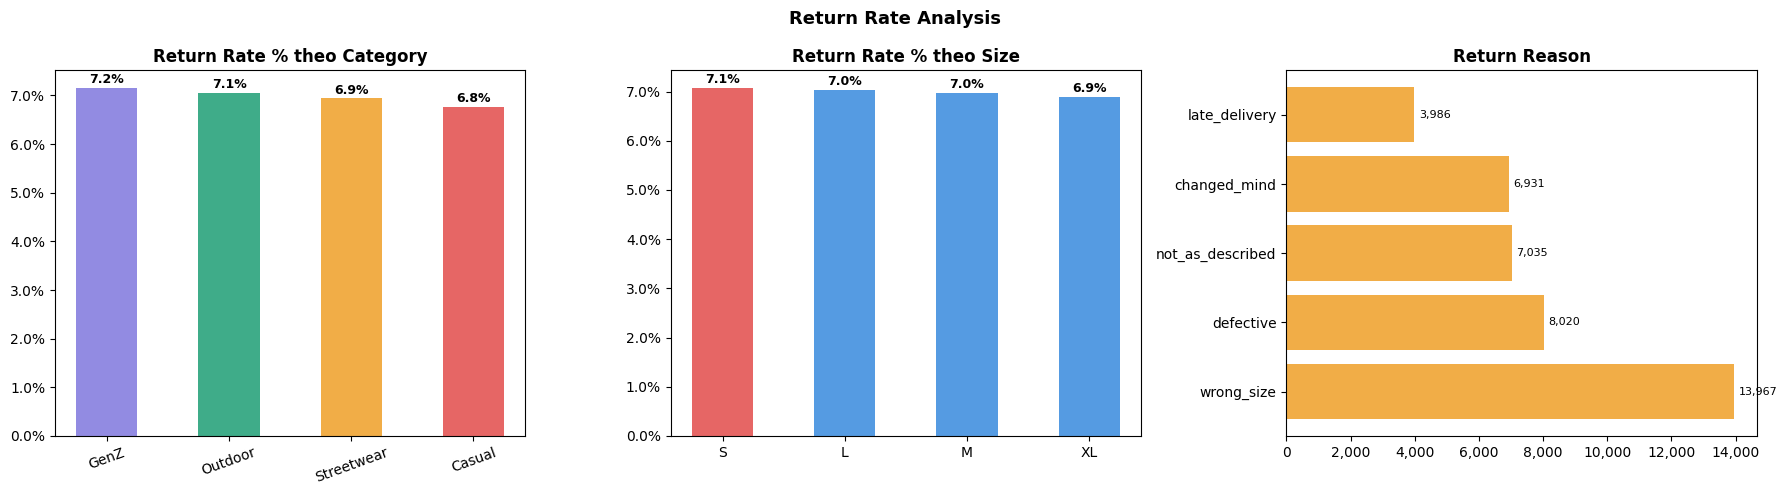

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Return Rate Analysis', fontsize=13, fontweight='bold')

# Theo Category
ax = axes[0]
rrc = return_rate_cat.reset_index()
bars = ax.bar(rrc['category'], rrc['return_rate%'],
              color=C_CAT[:len(rrc)], alpha=0.85, width=0.5)
ax.set_title('Return Rate % theo Category', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.1f}%'))
ax.tick_params(axis='x', rotation=20)
for bar, val in zip(bars, rrc['return_rate%']):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.1,
            f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Theo Size
ax = axes[1]
if returned_by_size is not None:
    rrs = return_rate_size.reset_index()
    bars = ax.bar(rrs['size'], rrs['return_rate%'],
                  color=[C_BAD if v == rrs['return_rate%'].max() else C_GOOD
                         for v in rrs['return_rate%']],
                  alpha=0.85, width=0.5)
    ax.set_title('Return Rate % theo Size', fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.1f}%'))
    for bar, val in zip(bars, rrs['return_rate%']):
        ax.text(bar.get_x()+bar.get_width()/2, val+0.1,
                f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Theo Return Reason
ax = axes[2]
reason_counts = ret['return_reason'].value_counts()
bars = ax.barh(reason_counts.index, reason_counts.values,
               color=C_WARN, alpha=0.85)
ax.set_title('Return Reason', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
for bar, val in zip(bars, reason_counts.values):
    ax.text(val + reason_counts.max()*0.01,
            bar.get_y()+bar.get_height()/2,
            f'{val:,}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

## 4. Giao trễ → Trả hàng nhiều hơn không?

**BA team hỏi:** Cứ giao hàng trễ là khách trả lại hàng?  
Join shipments với returns để kiểm tra correlation.

In [6]:
# Với mỗi order, lấy lead_time và xem có return không
ship_valid2 = ship[ship['lead_time_days'].between(0, 60)][['order_id','lead_time_days','region']]
ship_valid2['is_returned'] = ship_valid2['order_id'].isin(returns['order_id'].unique())

# Chia lead time thành bucket
buckets = [0, 2, 5, 10, 20, 60]
labels  = ['0-2d','3-5d','6-10d','11-20d','>20d']
ship_valid2['lt_bucket'] = pd.cut(ship_valid2['lead_time_days'],
                                   bins=buckets, labels=labels)

bucket_stats = ship_valid2.groupby('lt_bucket', observed=True).agg(
    n_orders    = ('order_id', 'count'),
    n_returned  = ('is_returned', 'sum'),
).reset_index()
bucket_stats['return_rate%'] = bucket_stats['n_returned'] / bucket_stats['n_orders'] * 100

print('Return Rate theo Lead Time bucket:')
print(bucket_stats.round(2).to_string(index=False))

# Correlation (point-biserial)
corr, pval = stats.pointbiserialr(
    ship_valid2['lead_time_days'],
    ship_valid2['is_returned'].astype(int)
)
print(f'\nCorrelation lead_time vs is_returned: {corr:.4f} (p={pval:.4f})')
print('(dương = lead time dài hơn thì trả hàng nhiều hơn)')

Return Rate theo Lead Time bucket:
lt_bucket  n_orders  n_returned  return_rate%
     0-2d     94299        5983          6.34
     3-5d    283249       18195          6.42
    6-10d    188519       11884          6.30

Correlation lead_time vs is_returned: -0.0026 (p=0.0548)
(dương = lead time dài hơn thì trả hàng nhiều hơn)


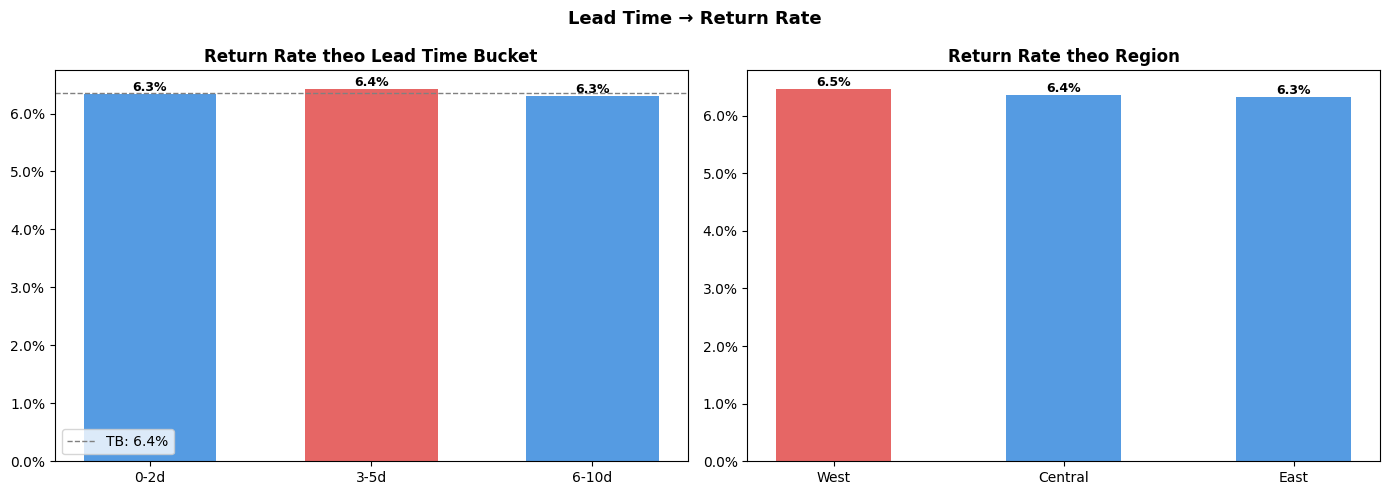

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Lead Time → Return Rate', fontsize=13, fontweight='bold')

ax = axes[0]
bars = ax.bar(bucket_stats['lt_bucket'].astype(str),
              bucket_stats['return_rate%'],
              color=[C_BAD if v > bucket_stats['return_rate%'].mean() else C_GOOD
                     for v in bucket_stats['return_rate%']],
              alpha=0.85, width=0.6)
ax.set_title('Return Rate theo Lead Time Bucket', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.1f}%'))
ax.axhline(bucket_stats['return_rate%'].mean(), color='gray',
           linestyle='--', lw=1, label=f'TB: {bucket_stats["return_rate%"].mean():.1f}%')
ax.legend()
for bar, val in zip(bars, bucket_stats['return_rate%']):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.05,
            f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Return rate theo region
ret_region = ship_valid2.groupby(
    ship_valid2['order_id'].map(dict(zip(ship['order_id'], ship['region'])))
).agg(n_orders=('order_id','count'), n_returned=('is_returned','sum')).reset_index()
ret_region.columns = ['region','n_orders','n_returned']
ret_region['return_rate%'] = ret_region['n_returned'] / ret_region['n_orders'] * 100
ret_region = ret_region.dropna().sort_values('return_rate%', ascending=False)

ax = axes[1]
bars = ax.bar(ret_region['region'].astype(str),
              ret_region['return_rate%'],
              color=[C_BAD if v == ret_region['return_rate%'].max() else C_GOOD
                     for v in ret_region['return_rate%']],
              alpha=0.85, width=0.5)
ax.set_title('Return Rate theo Region', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.1f}%'))
for bar, val in zip(bars, ret_region['return_rate%']):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.05,
            f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Stockout Analysis — tổng quan và theo Category

**BA team hỏi:** Stockout rate có đồng đều giữa 4 category không, dù sức bán khác nhau?

In [8]:
# inventory đã có cột category (pre-joined bởi BTC)
inventory['Year']  = inventory['snapshot_date'].dt.year
inventory['Month'] = inventory['snapshot_date'].dt.month
inventory['YearMonth'] = inventory['snapshot_date'].dt.to_period('M')

# Stockout rate = stockout_days / 30 (tháng)
inventory['stockout_rate'] = inventory['stockout_days'] / 30

print('Inventory overview:')
print(inventory[['stock_on_hand','stockout_days','fill_rate',
                  'stockout_flag','overstock_flag']].describe().round(2).to_string())

print(f'\nTổng snapshots         : {len(inventory):,}')
print(f'% snapshot có stockout : {inventory["stockout_flag"].mean()*100:.1f}%')
print(f'% snapshot overstock   : {inventory["overstock_flag"].mean()*100:.1f}%')

# Theo category
stockout_cat = inventory.groupby('category').agg(
    n_snapshots      = ('snapshot_date', 'count'),
    stockout_flag_pct= ('stockout_flag', 'mean'),
    overstock_pct    = ('overstock_flag', 'mean'),
    avg_stockout_days= ('stockout_days', 'mean'),
    avg_fill_rate    = ('fill_rate', 'mean'),
    avg_sell_through = ('sell_through_rate', 'mean'),
).reset_index()
stockout_cat['stockout_flag_pct'] *= 100
stockout_cat['overstock_pct'] *= 100

print('\nStockout theo Category:')
print(stockout_cat.round(2).to_string(index=False))

Inventory overview:
       stock_on_hand  stockout_days  fill_rate  stockout_flag  overstock_flag
count      60,247.00      60,247.00  60,247.00      60,247.00       60,247.00
mean          189.30           1.16       0.96           0.67            0.76
std           316.98           1.62       0.05           0.47            0.43
min             3.00           0.00       0.07           0.00            0.00
25%            15.00           0.00       0.93           0.00            1.00
50%            62.00           1.00       0.97           1.00            1.00
75%           210.00           2.00       1.00           1.00            1.00
max         2,673.00          28.00       1.00           1.00            1.00

Tổng snapshots         : 60,247
% snapshot có stockout : 67.3%
% snapshot overstock   : 76.3%

Stockout theo Category:
  category  n_snapshots  stockout_flag_pct  overstock_pct  avg_stockout_days  avg_fill_rate  avg_sell_through
    Casual         3503              66.20      

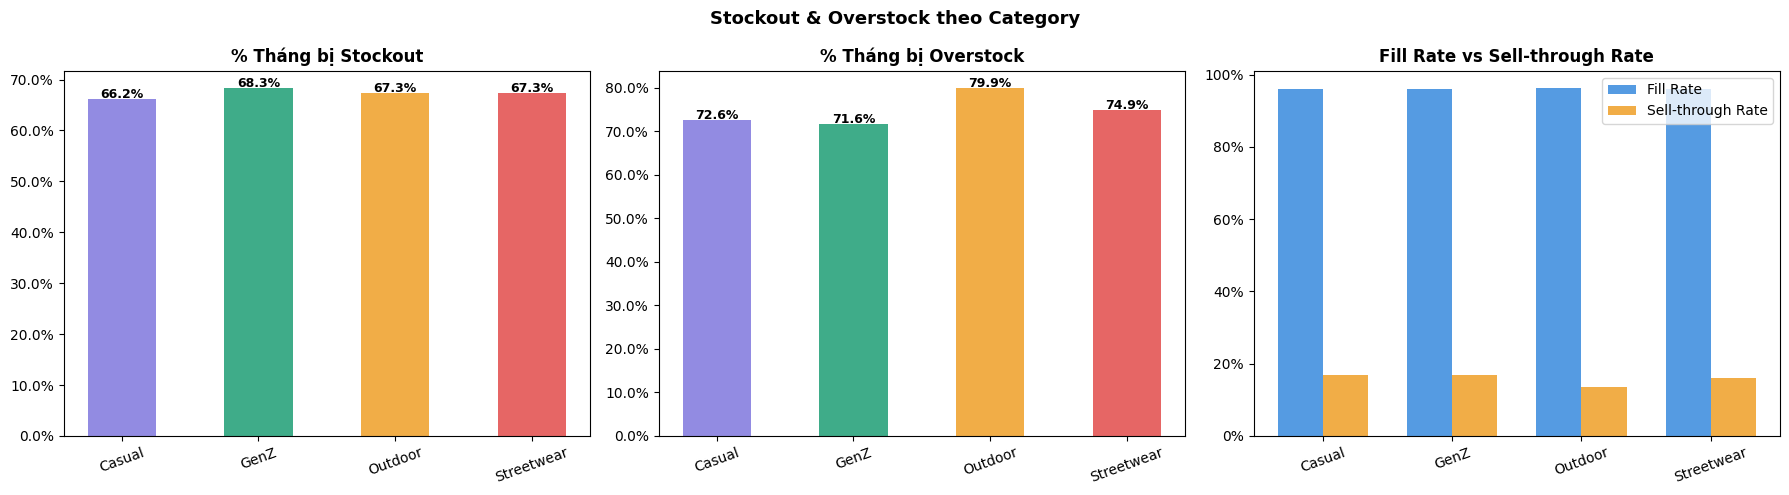


💡 Nếu stockout đồng đều dù sức bán khác nhau → reorder policy đang áp cứng như nhau cho mọi category


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Stockout & Overstock theo Category', fontsize=13, fontweight='bold')

cats = stockout_cat['category'].tolist()

# Stockout flag %
ax = axes[0]
bars = ax.bar(cats, stockout_cat['stockout_flag_pct'],
              color=C_CAT[:len(cats)], alpha=0.85, width=0.5)
ax.set_title('% Tháng bị Stockout', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.1f}%'))
ax.tick_params(axis='x', rotation=20)
for bar, val in zip(bars, stockout_cat['stockout_flag_pct']):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.2,
            f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Overstock flag %
ax = axes[1]
bars = ax.bar(cats, stockout_cat['overstock_pct'],
              color=C_CAT[:len(cats)], alpha=0.85, width=0.5)
ax.set_title('% Tháng bị Overstock', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.1f}%'))
ax.tick_params(axis='x', rotation=20)
for bar, val in zip(bars, stockout_cat['overstock_pct']):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.2,
            f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Fill rate vs Sell-through
ax = axes[2]
x = np.arange(len(cats))
w = 0.35
ax.bar(x - w/2, stockout_cat['avg_fill_rate']*100,
       width=w, label='Fill Rate', color=C_GOOD, alpha=0.85)
ax.bar(x + w/2, stockout_cat['avg_sell_through']*100,
       width=w, label='Sell-through Rate', color=C_WARN, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(cats, rotation=20)
ax.set_title('Fill Rate vs Sell-through Rate', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}%'))
ax.legend()

plt.tight_layout()
plt.show()
print('\n💡 Nếu stockout đồng đều dù sức bán khác nhau → reorder policy đang áp cứng như nhau cho mọi category')

## 6. Stockout trend theo thời gian và correlation với web traffic

**BA team hỏi:** Tìm correlation giữa monthly stockout rate với monthly conversion/bounce rate.  
Stockout có phải factor làm mất KH không?

In [10]:
# Monthly stockout rate
monthly_stock = inventory.groupby('YearMonth').agg(
    stockout_flag_pct = ('stockout_flag', 'mean'),
    avg_stockout_days = ('stockout_days', 'mean'),
    avg_fill_rate     = ('fill_rate', 'mean'),
).reset_index()
monthly_stock['Date'] = monthly_stock['YearMonth'].dt.to_timestamp()

# Monthly web traffic metrics
web['YearMonth'] = web['date'].dt.to_period('M')
monthly_web = web.groupby('YearMonth').agg(
    sessions      = ('sessions', 'sum'),
    bounce_rate   = ('bounce_rate', 'mean'),
    avg_session_duration = ('avg_session_duration_sec', 'mean'),
).reset_index()

# Monthly orders (để tính conversion)
orders['YearMonth'] = orders['order_date'].dt.to_period('M')
monthly_orders = orders[orders['order_status']=='delivered'].groupby('YearMonth').agg(
    n_orders = ('order_id','count')
).reset_index()

monthly_web = monthly_web.merge(monthly_orders, on='YearMonth', how='left')
monthly_web['conversion_rate'] = monthly_web['n_orders'] / monthly_web['sessions'] * 100

# Merge stockout với web
monthly_merged = monthly_stock.merge(monthly_web, on='YearMonth', how='inner')
print(f'Merged monthly data: {len(monthly_merged)} tháng')
print(monthly_merged[['YearMonth','stockout_flag_pct','bounce_rate',
                        'conversion_rate','avg_fill_rate']].head(10).to_string(index=False))

Merged monthly data: 120 tháng
YearMonth  stockout_flag_pct  bounce_rate  conversion_rate  avg_fill_rate
  2013-01               0.64         0.00             1.00           0.97
  2013-02               0.71         0.00             0.89           0.96
  2013-03               0.71         0.00             0.85           0.96
  2013-04               0.70         0.00             0.87           0.95
  2013-05               0.68         0.00             0.82           0.96
  2013-06               0.66         0.00             0.84           0.96
  2013-07               0.69         0.00             0.90           0.96
  2013-08               0.65         0.00             0.86           0.96
  2013-09               0.65         0.00             0.90           0.97
  2013-10               0.68         0.00             0.91           0.96


In [11]:
# Correlation matrix
corr_cols = ['stockout_flag_pct','avg_stockout_days','avg_fill_rate',
             'bounce_rate','conversion_rate','sessions']
corr_matrix = monthly_merged[corr_cols].corr()

print('Correlation Matrix (stockout vs traffic metrics):')
print(corr_matrix.round(3).to_string())

# Highlight correlations quan trọng
print('\nCorrelations quan trọng với Stockout Rate:')
for col in ['bounce_rate','conversion_rate','sessions']:
    r = monthly_merged['stockout_flag_pct'].corr(monthly_merged[col])
    sig = '⚠️ đáng chú ý' if abs(r) > 0.3 else ''
    print(f'  stockout_flag_pct vs {col:<22}: {r:+.3f} {sig}')

Correlation Matrix (stockout vs traffic metrics):
                   stockout_flag_pct  avg_stockout_days  avg_fill_rate  bounce_rate  conversion_rate  sessions
stockout_flag_pct               1.00               0.57          -0.57        -0.03             0.18      0.14
avg_stockout_days               0.57               1.00          -1.00        -0.12             0.49      0.12
avg_fill_rate                  -0.57              -1.00           1.00         0.12            -0.49     -0.12
bounce_rate                    -0.03              -0.12           0.12         1.00            -0.15     -0.04
conversion_rate                 0.18               0.49          -0.49        -0.15             1.00     -0.44
sessions                        0.14               0.12          -0.12        -0.04            -0.44      1.00

Correlations quan trọng với Stockout Rate:
  stockout_flag_pct vs bounce_rate           : -0.032 
  stockout_flag_pct vs conversion_rate       : +0.185 
  stockout_flag_pct

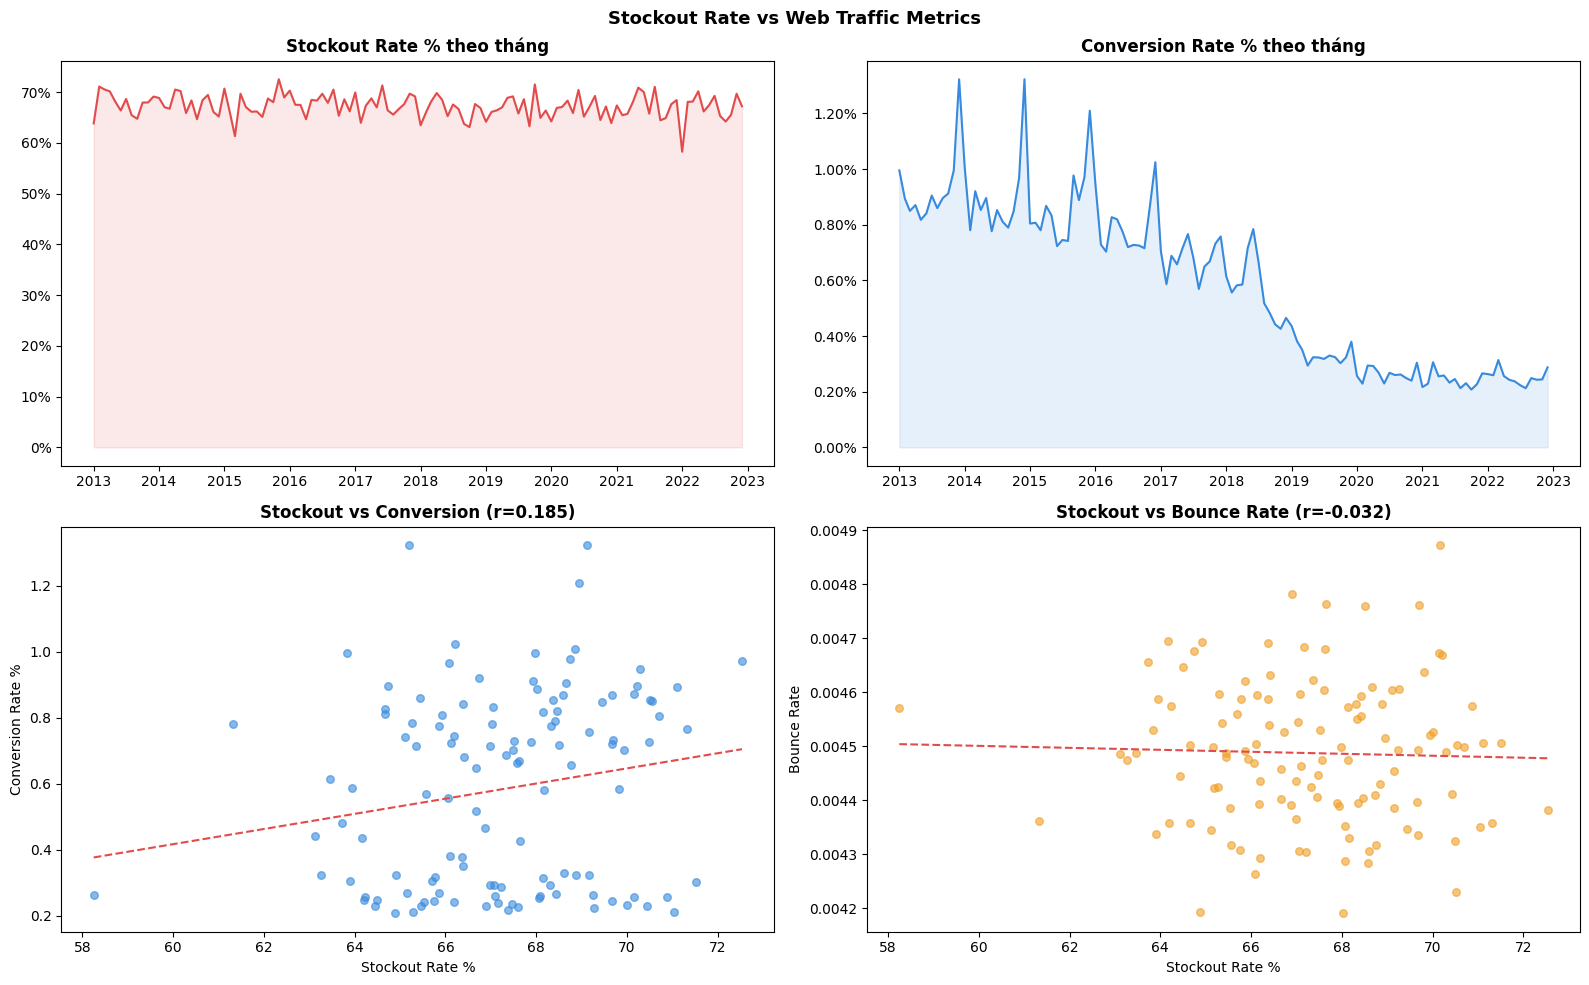

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Stockout Rate vs Web Traffic Metrics', fontsize=13, fontweight='bold')

date_col = monthly_merged['Date']

# Stockout trend
ax = axes[0][0]
ax.plot(date_col, monthly_merged['stockout_flag_pct']*100,
        color=C_BAD, linewidth=1.5)
ax.fill_between(date_col, monthly_merged['stockout_flag_pct']*100,
                alpha=0.12, color=C_BAD)
ax.set_title('Stockout Rate % theo tháng', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}%'))

# Conversion rate trend
ax = axes[0][1]
ax.plot(date_col, monthly_merged['conversion_rate'],
        color=C_GOOD, linewidth=1.5)
ax.fill_between(date_col, monthly_merged['conversion_rate'],
                alpha=0.12, color=C_GOOD)
ax.set_title('Conversion Rate % theo tháng', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.2f}%'))

# Scatter: stockout vs conversion
ax = axes[1][0]
ax.scatter(monthly_merged['stockout_flag_pct']*100,
           monthly_merged['conversion_rate'],
           color=C_GOOD, alpha=0.6, s=30)
z = np.polyfit(monthly_merged['stockout_flag_pct'].dropna()*100,
               monthly_merged['conversion_rate'].dropna(), 1)
p = np.poly1d(z)
xline = np.linspace(monthly_merged['stockout_flag_pct'].min()*100,
                    monthly_merged['stockout_flag_pct'].max()*100, 100)
ax.plot(xline, p(xline), color=C_BAD, linestyle='--', lw=1.5)
r_val = monthly_merged['stockout_flag_pct'].corr(monthly_merged['conversion_rate'])
ax.set_title(f'Stockout vs Conversion (r={r_val:.3f})', fontweight='bold')
ax.set_xlabel('Stockout Rate %')
ax.set_ylabel('Conversion Rate %')

# Scatter: stockout vs bounce
ax = axes[1][1]
ax.scatter(monthly_merged['stockout_flag_pct']*100,
           monthly_merged['bounce_rate'],
           color=C_WARN, alpha=0.6, s=30)
z2 = np.polyfit(monthly_merged['stockout_flag_pct'].dropna()*100,
                monthly_merged['bounce_rate'].dropna(), 1)
p2 = np.poly1d(z2)
ax.plot(xline, p2(xline), color=C_BAD, linestyle='--', lw=1.5)
r_val2 = monthly_merged['stockout_flag_pct'].corr(monthly_merged['bounce_rate'])
ax.set_title(f'Stockout vs Bounce Rate (r={r_val2:.3f})', fontweight='bold')
ax.set_xlabel('Stockout Rate %')
ax.set_ylabel('Bounce Rate')

plt.tight_layout()
plt.show()

## 7. Return Rate theo thời gian — có trend xấu dần không?

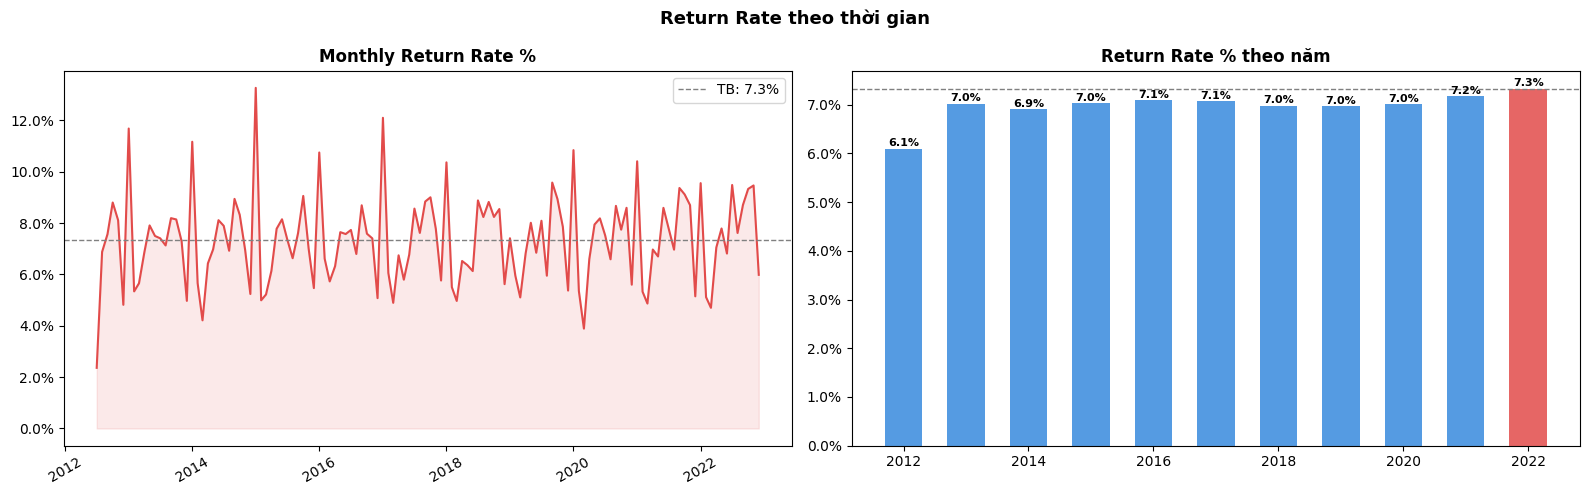

Return Rate theo năm:
 Year  n_returned  n_delivered  return_rate%
 2012        1564        25663          6.09
 2013        4327        61588          7.03
 2014        4473        64688          6.91
 2015        4657        66163          7.04
 2016        4684        66067          7.09
 2017        4324        61144          7.07
 2018        3893        55740          6.98
 2019        2317        33259          6.97
 2020        1961        27975          7.01
 2021        1920        26741          7.18
 2022        2030        27688          7.33


In [13]:
# Monthly return rate = returns / delivered
monthly_returns = ret.groupby('YearMonth').agg(
    n_returns = ('return_id', 'count'),
    n_orders_returned = ('order_id', 'nunique'),
    refund_sum = ('refund_amount', 'sum'),
).reset_index()

monthly_delivered = orders[orders['order_status']=='delivered'].copy()
monthly_delivered['YearMonth'] = monthly_delivered['order_date'].dt.to_period('M')
monthly_del_count = monthly_delivered.groupby('YearMonth').size().reset_index(name='n_delivered')

monthly_ret_rate = monthly_returns.merge(monthly_del_count, on='YearMonth', how='left')
monthly_ret_rate['return_rate%'] = (
    monthly_ret_rate['n_orders_returned'] / monthly_ret_rate['n_delivered'] * 100
)
monthly_ret_rate['Date'] = monthly_ret_rate['YearMonth'].dt.to_timestamp()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Return Rate theo thời gian', fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(monthly_ret_rate['Date'], monthly_ret_rate['return_rate%'],
        color=C_BAD, linewidth=1.5)
ax.fill_between(monthly_ret_rate['Date'], monthly_ret_rate['return_rate%'],
                alpha=0.12, color=C_BAD)
mean_rr = monthly_ret_rate['return_rate%'].mean()
ax.axhline(mean_rr, color='gray', linestyle='--', lw=1,
           label=f'TB: {mean_rr:.1f}%')
ax.set_title('Monthly Return Rate %', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.1f}%'))
ax.legend()
ax.tick_params(axis='x', rotation=30)

# Return rate theo năm
ret['Year'] = ret['return_date'].dt.year
annual_ret = ret.groupby('Year')['order_id'].nunique().reset_index(name='n_returned')
annual_del = orders[orders['order_status']=='delivered'].copy()
annual_del['Year'] = annual_del['order_date'].dt.year
annual_del_cnt = annual_del.groupby('Year').size().reset_index(name='n_delivered')
annual_ret_rate = annual_ret.merge(annual_del_cnt, on='Year')
annual_ret_rate['return_rate%'] = annual_ret_rate['n_returned']/annual_ret_rate['n_delivered']*100

ax = axes[1]
ax.bar(annual_ret_rate['Year'], annual_ret_rate['return_rate%'],
       color=[C_BAD if v > mean_rr else C_GOOD for v in annual_ret_rate['return_rate%']],
       alpha=0.85, width=0.6)
ax.set_title('Return Rate % theo năm', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.1f}%'))
ax.axhline(mean_rr, color='gray', linestyle='--', lw=1)
for x, y in zip(annual_ret_rate['Year'], annual_ret_rate['return_rate%']):
    ax.text(x, y+0.05, f'{y:.1f}%', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

print('Return Rate theo năm:')
print(annual_ret_rate[['Year','n_returned','n_delivered','return_rate%']].round(2).to_string(index=False))

## 8. Tổng kết Chặng 3

In [15]:
print('='*65)
print('📋  CHẶNG 3 — TỔNG KẾT PHÁT HIỆN')
print('='*65)

print(f'''
1. DELIVERY LEAD TIME
   Median lead time: {ship_valid['lead_time_days'].median():.0f} ngày
   % giao trong 3 ngày : {(ship_valid["lead_time_days"]<=3).mean()*100:.1f}%
   % giao trong 7 ngày : {(ship_valid["lead_time_days"]<=7).mean()*100:.1f}%
   → Region nào chậm nhất: xem Section 2
   → Lead time có tệ hơn theo năm không: xem trend chart

2. RETURN RATE
   Return rate tổng thể: {n_returned_orders/n_delivered*100:.2f}%
   Top lý do: wrong_size, defective, not_as_described
   → Size nào return nhiều nhất: xem Section 3
   → Giao trễ có làm tăng return không: xem correlation Section 4

3. STOCKOUT
   % tháng bị stockout: xem Section 5
   → Có đồng đều giữa 4 category không?
   → Nếu đồng đều dù sức bán khác nhau → reorder policy cứng nhắc

4. STOCKOUT vs TRAFFIC CORRELATION
   Correlation stockout vs conversion: xem Section 6
   Correlation stockout vs bounce rate: xem Section 6
   → Nếu r > 0.3: stockout là factor đáng kể
   → Nếu r gần 0: stockout không phải nguyên nhân chính mất KH

5. RETURN TREND
   → Return rate có tăng theo năm không: xem Section 7
   → Nếu tăng cùng lúc với Revenue drop (2019) → vận hành đang xấu đi
''')
print('='*65)
print('→ BƯỚC TIẾP THEO: Chặng 4 — Feature Engineering cho Model')
print('   File: 05_chang4_features.ipynb')
print('='*65)

📋  CHẶNG 3 — TỔNG KẾT PHÁT HIỆN

1. DELIVERY LEAD TIME
   Median lead time: 4 ngày
   % giao trong 3 ngày : 33.3%
   % giao trong 7 ngày : 100.0%
   → Region nào chậm nhất: xem Section 2
   → Lead time có tệ hơn theo năm không: xem trend chart

2. RETURN RATE
   Return rate tổng thể: 6.98%
   Top lý do: wrong_size, defective, not_as_described
   → Size nào return nhiều nhất: xem Section 3
   → Giao trễ có làm tăng return không: xem correlation Section 4

3. STOCKOUT
   % tháng bị stockout: xem Section 5
   → Có đồng đều giữa 4 category không?
   → Nếu đồng đều dù sức bán khác nhau → reorder policy cứng nhắc

4. STOCKOUT vs TRAFFIC CORRELATION
   Correlation stockout vs conversion: xem Section 6
   Correlation stockout vs bounce rate: xem Section 6
   → Nếu r > 0.3: stockout là factor đáng kể
   → Nếu r gần 0: stockout không phải nguyên nhân chính mất KH

5. RETURN TREND
   → Return rate có tăng theo năm không: xem Section 7
   → Nếu tăng cùng lúc với Revenue drop (2019) → vận hành đang